In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

SHORT_MODEL_NAMES = {
    "LLMPredict/Base/": "Qwen3 - Base",
    "LLMPredict/FineTuned/": "Qwen3 - Fine-Tuned",
    "RescorlaWagnerResults/": "Rescorla-Wagner",
    "EvolvedCogModel/Base/": "OpenEvolve - Base",
    "EvolvedCogModel/FineTuned/": "OpenEvolve - Fine-Tuned",
}

experiments = [
    {'name': 'TwoBandit', 'experiment': 'exp1', 'num_options': 2, 'held-out': False},
    {'name': 'TwoBandit', 'experiment': 'exp2', 'num_options': 2, 'held-out': False},
    {'name': 'DriftingBandit', 'experiment': 'exp0', 'num_options': 4, 'held-out': False},
    {'name': 'HorizonSomer', 'experiment': 'exp0', 'num_options': 2, 'held-out': False},
    {'name': 'HorizonWaltz', 'experiment': 'exp0', 'num_options': 2, 'held-out': False},
    {'name': 'HorizonSade', 'experiment': 'exp0', 'num_options': 2, 'held-out': True},
    {'name': 'HorizonFeng', 'experiment': 'exp0', 'num_options': 2, 'held-out': True},
    {'name': 'ChangingBandit', 'experiment': 'exp0', 'num_options': 2, 'held-out': True},
    {'name': 'MaggiesFarm', 'experiment': 'exp0', 'num_options': 3, 'held-out': True},
]
data_paths = ['LLMPredict/Base/', 'LLMPredict/FineTuned/', 'RescorlaWagnerResults/', 'EvolvedCogModel/FineTuned/', 'EvolvedCogModel/Base/']

repo_url = (
    "https://huggingface.co/datasets/"
    "cObliUvA/llm-guided-modelling-results/resolve/main"
)

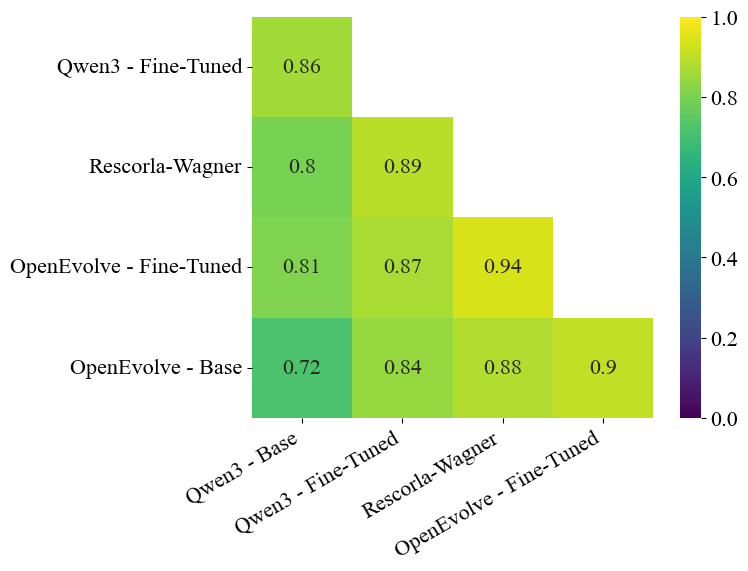

In [ ]:
from scipy.special import softmax

# ----------- LOAD & ALIGN DATA -----------
all_probs = {}

for exp in experiments:

    exp_id = f"{exp['name']}_{exp['experiment']}"

    model_data = {}
    reference_alignment = None

    for dp in data_paths:

        df = pd.read_csv(f"{repo_url}/{dp}{exp_id}.csv")

        sort_cols = ["participant"]

        if "game" in df.columns:
            sort_cols.append("game")

        if "trial" in df.columns:
            sort_cols.append("trial")

        df = df.sort_values(sort_cols).reset_index(drop=True)

        df["obs_idx"] = (
            df.groupby("participant")
              .cumcount()
        )

        current_alignment = df[
            ["participant", "obs_idx", "human_choice"]
        ].copy()

        if reference_alignment is None:
            reference_alignment = current_alignment
        else:
            assert len(reference_alignment) == len(current_alignment)

            assert np.array_equal(
                reference_alignment["participant"].to_numpy(),
                current_alignment["participant"].to_numpy()
            )

            assert np.array_equal(
                reference_alignment["human_choice"].to_numpy(),
                current_alignment["human_choice"].to_numpy()
            )

        model_name = SHORT_MODEL_NAMES.get(
            dp,
            "Unknown Model"
        )

        logit_cols = sorted(
            c for c in df.columns
            if "Log" in c
        )

        logits = df[logit_cols].to_numpy()

        if "LLMPredict" in dp:

            probs = np.exp(
                logits -
                df["lse"].to_numpy()[:, None]
            )

        else:

            probs = softmax(
                logits,
                axis=1
            )

        model_data[model_name] = probs

    all_probs[exp_id] = model_data

models = [
    SHORT_MODEL_NAMES.get(dp, "Unknown Model")
    for dp in data_paths
]

# ----------- COMPUTE CORRELATIONS -----------
corr_sum = pd.DataFrame(
    0.0,
    index=models,
    columns=models
)

n_exp = len(all_probs)

for exp_id in all_probs:

    for m1, p1 in all_probs[exp_id].items():

        v1 = p1.flatten()

        for m2, p2 in all_probs[exp_id].items():

            v2 = p2.flatten()

            corr_sum.loc[m1, m2] += np.corrcoef(
                v1,
                v2
            )[0, 1]

corr_mean = corr_sum / n_exp

mask = np.triu(
    np.ones_like(corr_mean, dtype=bool)
)

# ----------- PLOT -----------
plt.figure(figsize=(8, 6))
plt.rcParams.update({
    "font.family": "serif",
    "font.serif" : "Times New Roman",
    "font.size": 16,       # default text
    "axes.labelsize": 18,  # axis labels
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

ax = sns.heatmap(
    corr_mean.iloc[1:,:-1],
    mask=mask[1:,:-1],
    annot=True,
    square=True,
    cmap="viridis",
    vmin=0,
    vmax=1
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

ax.set_yticklabels(
    ax.get_yticklabels(),
)

plt.tight_layout()
plt.savefig(
    "../Images/correlation_heatmap.png",
    transparent=True,
    bbox_inches="tight",
    dpi=300
)
plt.show()

In [4]:
import statsmodels.formula.api as smf
all_data = {}

for exp in experiments:

    exp_id = f"{exp['name']}_{exp['experiment']}"
    models = {}
    reference_alignment = None

    for dp in data_paths:

        df = pd.read_csv(f"{repo_url}/{dp}{exp_id}.csv")

        sort_cols = ["participant"]

        if "game" in df.columns:
            sort_cols.append("game")

        if "trial" in df.columns:
            sort_cols.append("trial")

        df = df.sort_values(sort_cols).reset_index(drop=True)
        df["obs_idx"] = df.groupby("participant").cumcount()

        current_alignment = df[
            ["participant", "obs_idx", "human_choice"]
        ].copy()

        if reference_alignment is None:
            reference_alignment = current_alignment
        else:
            assert len(reference_alignment) == len(current_alignment)
            assert np.array_equal(
                reference_alignment["participant"].to_numpy(),
                current_alignment["participant"].to_numpy()
            )
            assert np.array_equal(
                reference_alignment["human_choice"].to_numpy(),
                current_alignment["human_choice"].to_numpy()
            )

        logit_cols = sorted(
            c for c in df.columns
            if "Log" in c
        )

        logits = df[logit_cols].to_numpy()

        if "LLMPredict" in dp:
            probs = np.exp(
                logits - df["lse"].to_numpy()[:, None]
            )
        else:
            probs = softmax(
                logits,
                axis=1
            )

        models[SHORT_MODEL_NAMES[dp]] = probs

    all_data[exp_id] = {
        "models": models,
        "alignment": reference_alignment.reset_index(drop=True)
    }


def tvd(a, b):
    return 0.5 * np.abs(a - b).sum(axis=1)


rows = []

for exp_id, data in all_data.items():

    models = data["models"]
    alignment = data["alignment"]

    L0 = models["Qwen3 - Base"]
    L1 = models["Qwen3 - Fine-Tuned"]
    C0 = models["OpenEvolve - Base"]
    C1 = models["OpenEvolve - Fine-Tuned"]

    distances = {
        "L0_C0": tvd(L0, C0),
        "L0_C1": tvd(L0, C1),
        "L1_C0": tvd(L1, C0),
        "L1_C1": tvd(L1, C1),
    }

    for i in range(len(alignment)):

        participant = alignment.loc[i, "participant"]
        obs_idx = alignment.loc[i, "obs_idx"]

        rows.append({
            "experiment": exp_id,
            "participant_uid": f"{exp_id}_{participant}",
            "trial_uid": f"{exp_id}_{participant}_{obs_idx}",
            "L0_C0": distances["L0_C0"][i],
            "L0_C1": distances["L0_C1"][i],
            "L1_C0": distances["L1_C0"][i],
            "L1_C1": distances["L1_C1"][i],
        })


df_wide = pd.DataFrame(rows)

df_wide["Cog0_mean"] = (
    df_wide["L0_C0"] +
    df_wide["L1_C0"]
) / 2

df_wide["Cog1_mean"] = (
    df_wide["L0_C1"] +
    df_wide["L1_C1"]
) / 2

df_wide["global_convergence"] = (
    df_wide["Cog1_mean"] -
    df_wide["Cog0_mean"]
)

df_wide["lineage"] = (
    (df_wide["L0_C0"] + df_wide["L1_C1"]) / 2
    -
    (df_wide["L0_C1"] + df_wide["L1_C0"]) / 2
)


print("\nMean distances")
print(
    df_wide[
        ["L0_C0", "L0_C1", "L1_C0", "L1_C1"]
    ].mean()
)
experiment_metrics = (
    df_wide
    .groupby("experiment")
    .agg({
        "L0_C0": "mean",
        "L0_C1": "mean",
        "L1_C0": "mean",
        "L1_C1": "mean",
        "global_convergence": "mean",
        "lineage": "mean"
    })
)

global_convergence = experiment_metrics["global_convergence"].mean()
lineage = experiment_metrics["lineage"].mean()

# Positive = lineage, negative = anti-lineage
relative_lineage = -lineage / abs(global_convergence)

print("\nExperiment-weighted mean distances")
print(
    experiment_metrics[
        ["L0_C0", "L0_C1", "L1_C0", "L1_C1"]
    ].mean()
)

print("\nExperiment-weighted metrics")
print(f"Global convergence : {global_convergence:.5f}")
print(f"Lineage            : {lineage:.5f}")
print(f"Relative lineage   : {relative_lineage:.5f}")

print("\nMetrics by experiment")
print(
    experiment_metrics[
        ["global_convergence", "lineage"]
    ]
)


Mean distances
L0_C0    0.251188
L0_C1    0.179527
L1_C0    0.254496
L1_C1    0.195344
dtype: float64

Experiment-weighted mean distances
L0_C0    0.209273
L0_C1    0.163309
L1_C0    0.177994
L1_C1    0.149312
dtype: float64

Experiment-weighted metrics
Global convergence : -0.03732
Lineage            : 0.00864
Relative lineage   : -0.23152

Metrics by experiment
                     global_convergence   lineage
experiment                                       
ChangingBandit_exp0           -0.065779  0.007515
DriftingBandit_exp0           -0.069980  0.012641
HorizonFeng_exp0              -0.024960  0.013574
HorizonSade_exp0              -0.016683  0.009299
HorizonSomer_exp0             -0.031478  0.015747
HorizonWaltz_exp0             -0.034718  0.004617
MaggiesFarm_exp0              -0.070974  0.003718
TwoBandit_exp1                -0.002035  0.001672
TwoBandit_exp2                -0.019302  0.008987
